# Prophet API Demonstration

This notebook demonstrates both the native Prophet API and our custom wrapper layer from `prophet_utils.py`.


**Author**: Ibrahim Ahmed Mohammed  
**Course**: DATA610  
**Dataset**: Johns Hopkins University COVID-19 Time Series (Jan 2020 - March 2023) (Updated from the Kaggle Dataset)

## Setup and Imports

In [15]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Native Prophet imports
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics

# Our wrapper utilities
from utils import (
    ProphetWrapper,
    load_jhu_timeseries,
    get_available_countries,
    prepare_prophet_data,
    create_intervention_dataframe,
    get_us_covid_interventions,
    calculate_rmse, calculate_mae, calculate_smape,
    plot_forecast
)

print("All imports successful!")

All imports successful!


## Part 1: Native Prophet API

First, let's demonstrate Prophet's native interface using real COVID-19 data from Johns Hopkins University.

### 1.1 Load Data with JHU Loader

In [16]:
# Load US COVID-19 data from Johns Hopkins
DATA_PATH = '/app/jhu_confirmed_global.csv'  # Update path as needed

df = load_jhu_timeseries(DATA_PATH, country='US')

print(f"Data shape: {df.shape}")
print(f"Date range: {df['ds'].min().date()} to {df['ds'].max().date()}")
print(f"Total days: {len(df)}")
df.head()

Data shape: (1143, 2)
Date range: 2020-01-22 to 2023-03-09
Total days: 1143


,ds,y
0,2020-01-22,0.0
1,2020-01-23,0.0
2,2020-01-24,1.0
3,2020-01-25,0.0
4,2020-01-26,3.0


In [17]:
# Check available countries
countries = get_available_countries(DATA_PATH)
print(f"Total countries available: {len(countries)}")
print(f"Sample countries: {countries[:10]}")

Total countries available: 201
Sample countries: ['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola', 'Antarctica', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia']


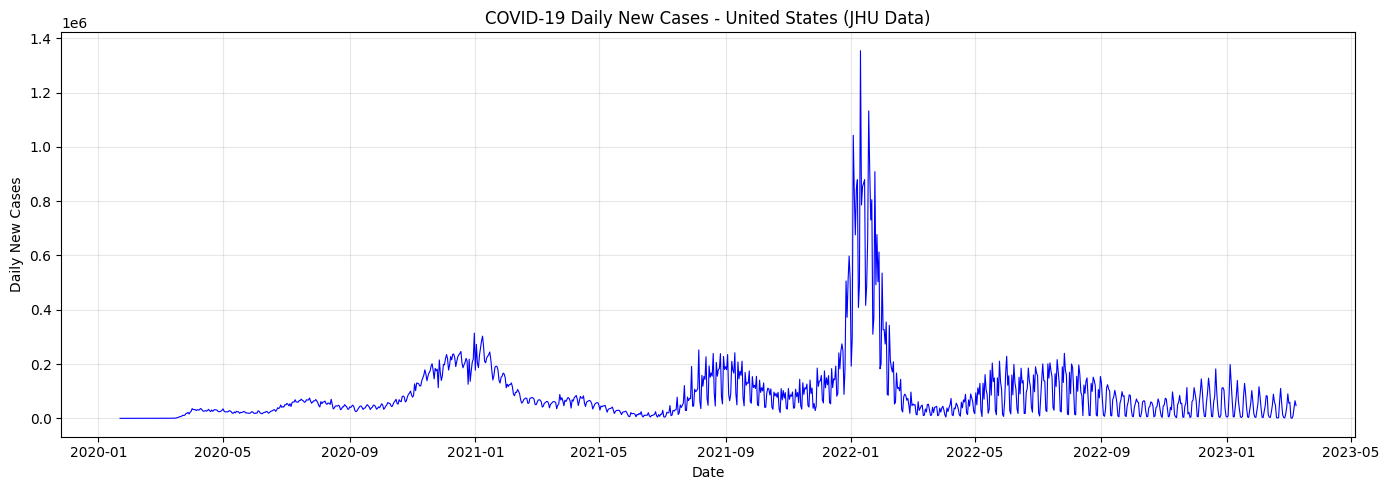

In [18]:
# Visualize the data
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['ds'], df['y'], 'b-', linewidth=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Daily New Cases')
ax.set_title('COVID-19 Daily New Cases - United States (JHU Data)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 1.2 Basic Prophet Model (Native API)

In [19]:
# Initialize Prophet with native API
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    interval_width=0.95
)

# Fit the model
model.fit(df)

print("Model fitted successfully!")

05:37:27 - cmdstanpy - INFO - Chain [1] start processing
05:37:27 - cmdstanpy - INFO - Chain [1] done processing


Model fitted successfully!


### 1.3 Generate Forecast

In [20]:
# Create future dataframe
future = model.make_future_dataframe(periods=30)  # 30 days ahead
print(f"Future dataframe shape: {future.shape}")

# Generate predictions
forecast = model.predict(future)

# Key columns in forecast
print("\nForecast columns:")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper', 'trend', 'weekly', 'yearly']].tail())

Future dataframe shape: (1173, 1)

Forecast columns:
             ds           yhat     yhat_lower    yhat_upper         trend  \
1168 2023-04-04  -97977.500029 -272352.436276  59148.565542 -51808.422252   
1169 2023-04-05  -78202.420035 -243144.077407  90232.428347 -52405.279563   
1170 2023-04-06  -88898.137220 -258749.838359  66610.714952 -53002.136875   
1171 2023-04-07  -87958.447770 -253563.963957  84407.143741 -53598.994186   
1172 2023-04-08 -142647.351982 -304993.742337  26237.538469 -54195.851498   

            weekly        yearly  
1168   5979.451216 -52148.528993  
1169  26038.970825 -51836.111297  
1170  15786.850590 -51682.850936  
1171  17316.128834 -51675.582417  
1172 -36654.577734 -51796.922750  


### 1.4 Native Visualization

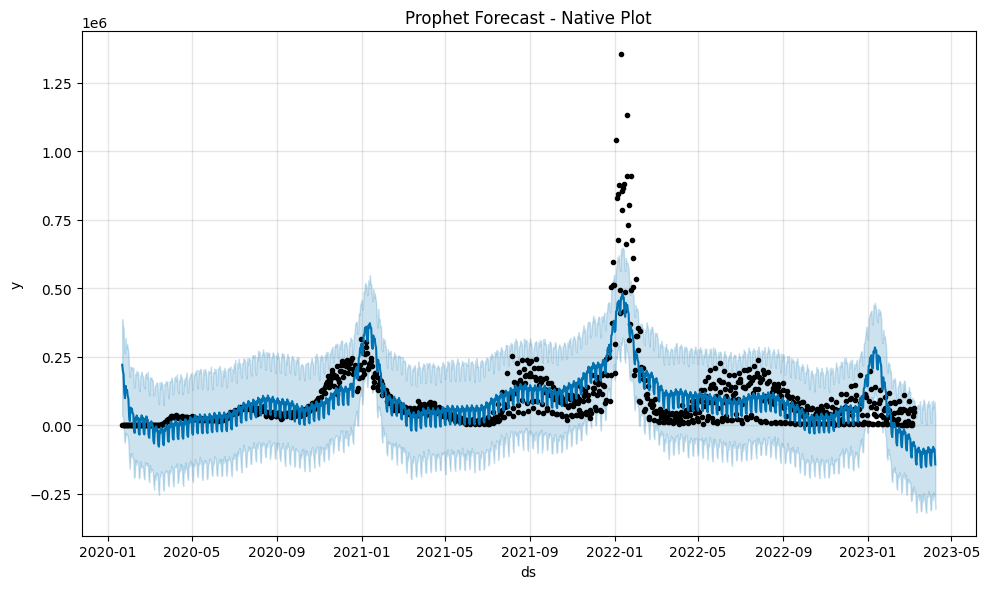

In [21]:
# Prophet's built-in plot
fig1 = model.plot(forecast)
plt.title('Prophet Forecast - Native Plot')
plt.tight_layout()
plt.show()

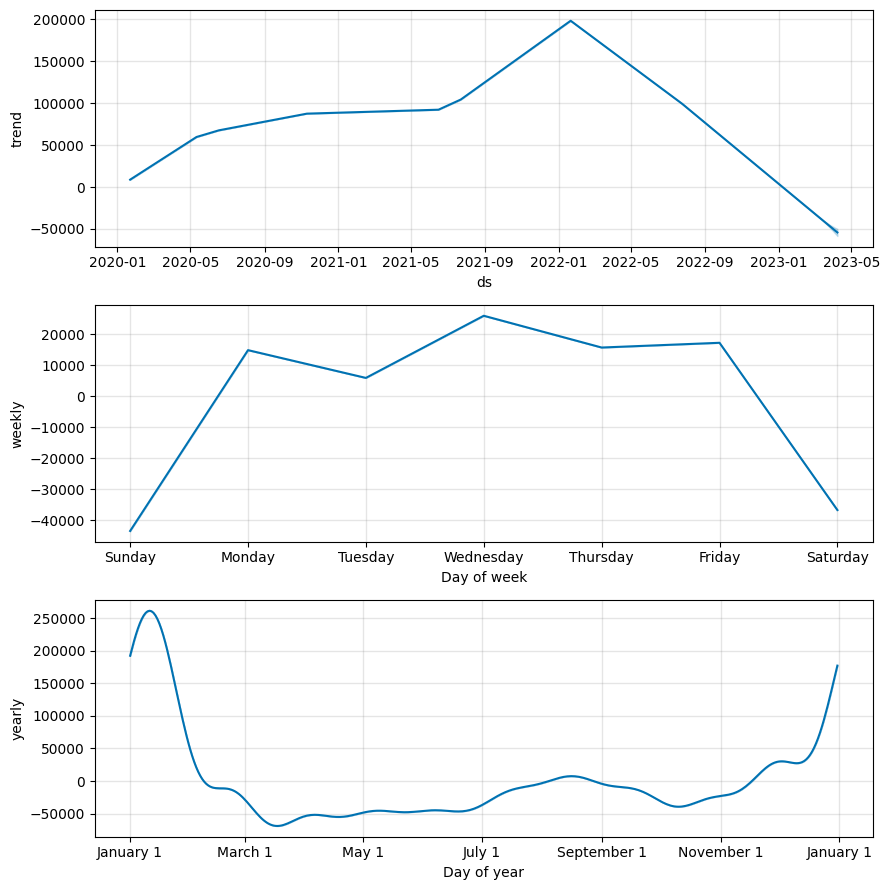

In [22]:
# Component plots
fig2 = model.plot_components(forecast)
plt.tight_layout()
plt.show()

### 1.5 Adding Holidays/Interventions (Native API)

In [23]:
# Define COVID interventions as holidays
holidays = pd.DataFrame({
    'holiday': ['national_emergency', 'lockdowns_begin', 'vaccine_rollout', 'delta_surge', 'omicron_surge'],
    'ds': pd.to_datetime(['2020-03-13', '2020-03-19', '2021-01-15', '2021-07-01', '2021-12-15']),
    'lower_window': 0,
    'upper_window': 14
})

# Model with holidays
model_holidays = Prophet(
    holidays=holidays,
    yearly_seasonality=True,
    weekly_seasonality=True
)
model_holidays.fit(df)

print("Holiday effects added!")
print(holidays)

05:37:28 - cmdstanpy - INFO - Chain [1] start processing
05:37:28 - cmdstanpy - INFO - Chain [1] done processing


Holiday effects added!
              holiday         ds  lower_window  upper_window
0  national_emergency 2020-03-13             0            14
1     lockdowns_begin 2020-03-19             0            14
2     vaccine_rollout 2021-01-15             0            14
3         delta_surge 2021-07-01             0            14
4       omicron_surge 2021-12-15             0            14


### 1.6 Adding External Regressors (Native API)

In [24]:
# Example: Add a synthetic regressor (e.g., stringency index)
df_with_regressor = df.copy()

# Create synthetic stringency index (higher during lockdowns)
df_with_regressor['stringency'] = 0.3  # baseline
df_with_regressor.loc[df_with_regressor['ds'] < '2020-06-01', 'stringency'] = 0.8  # initial lockdown
df_with_regressor.loc[(df_with_regressor['ds'] >= '2020-11-01') & (df_with_regressor['ds'] < '2021-03-01'), 'stringency'] = 0.6  # winter restrictions

# Model with regressor
model_reg = Prophet(yearly_seasonality=True, weekly_seasonality=True)
model_reg.add_regressor('stringency')
model_reg.fit(df_with_regressor)

# For prediction, must provide regressor values
future_reg = model_reg.make_future_dataframe(periods=30)
future_reg['stringency'] = 0.3  # assume baseline for future

forecast_reg = model_reg.predict(future_reg)
print("Model with regressor fitted!")

05:37:28 - cmdstanpy - INFO - Chain [1] start processing
05:37:28 - cmdstanpy - INFO - Chain [1] done processing


Model with regressor fitted!


### 1.7 Cross-Validation (Native API)

In [25]:
# Perform cross-validation
cv_results = cross_validation(
    model,
    initial='365 days',
    period='30 days',
    horizon='28 days'
)

print(f"CV results shape: {cv_results.shape}")
cv_results.head()

Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.


  0%|          | 0/25 [00:00<?, ?it/s]

05:37:28 - cmdstanpy - INFO - Chain [1] start processing
05:37:28 - cmdstanpy - INFO - Chain [1] done processing
05:37:28 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
05:37:28 - cmdstanpy - INFO - Chain [1] start processing
05:37:28 - cmdstanpy - INFO - Chain [1] done processing
05:37:28 - cmdstanpy - INFO - Chain [1] start processing
05:37:28 - cmdstanpy - INFO - Chain [1] done processing
05:37:28 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
05:37:28 - cmdstanpy - INFO - Chain [1] start processing
05:37:29 - cmdstanpy - INFO - Chain [1] done processing
05:37:29 - cmdstanpy - INFO - Chain [1] start processing
05:37:29 - cmdstanpy - INFO - Chain [1] done processing
05:37:29 - cmdstanpy - INFO - Chain [1] start processing
05:37:29 - cmdstanpy - INFO - Chain [1] done processing
05:37:29 - cmdstanpy - INFO - Chain [1] 

CV results shape: (700, 6)


,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2021-02-20,112803.032139,80296.549638,143779.577027,73581.0,2021-02-19
1,2021-02-21,100140.080797,68115.148520,130222.325071,55253.0,2021-02-19
2,2021-02-22,102951.039869,70421.181180,134009.445643,56056.0,2021-02-19
3,2021-02-23,111605.297797,80630.053248,141377.062461,73830.0,2021-02-19
4,2021-02-24,113563.691529,84315.241330,146762.257630,74981.0,2021-02-19


In [26]:
# Calculate performance metrics
metrics = performance_metrics(cv_results)
print("\nPerformance Metrics:")
metrics[['horizon', 'mse', 'rmse', 'mae', 'smape']].head(10)


Performance Metrics:


,horizon,mse,rmse,mae,smape
0,3 days,1.410941e+10,118783.051263,70907.235336,0.659341
1,4 days,1.753518e+10,132420.455816,78112.106826,0.656373
2,5 days,1.745997e+10,132136.164927,77585.670784,0.630962
3,6 days,1.455776e+10,120655.539185,76684.609469,0.669957
4,7 days,1.252439e+10,111912.403804,75615.523786,0.708731
5,8 days,1.081229e+10,103982.170264,74149.987642,0.730637
6,9 days,1.338017e+10,115672.698723,79464.884566,0.750053
7,10 days,1.411875e+10,118822.351096,80631.682560,0.744531
8,11 days,1.677163e+10,129505.321018,87352.578000,0.748135
9,12 days,1.420861e+10,119199.854855,83758.542387,0.732418


---

## Part 2: Wrapper Layer (`prophet_utils.py`)

Now let's demonstrate our simplified wrapper API designed for COVID-19 forecasting.

### 2.1 ProphetWrapper Class

In [27]:
# Initialize wrapper with sensible defaults for COVID data
wrapper = ProphetWrapper(
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.1,  # More flexible for volatile data
    interval_width=0.95
)

print("Wrapper configuration:")
print(wrapper.config)

Wrapper configuration:
{'weekly_seasonality': True, 'yearly_seasonality': True, 'daily_seasonality': False, 'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 10.0, 'holidays_prior_scale': 10.0, 'interval_width': 0.95}


### 2.2 Method Chaining with Interventions

In [28]:
# Get all US interventions using helper function
interventions = get_us_covid_interventions()
print("US COVID-19 Interventions:")
for name, date in interventions.items():
    print(f"  {name}: {date}")

US COVID-19 Interventions:
  national_emergency: 2020-03-13
  lockdowns_begin: 2020-03-19
  reopening_phase1: 2020-05-01
  summer_surge: 2020-07-01
  fall_surge: 2020-10-15
  vaccine_auth: 2020-12-11
  vaccine_rollout: 2021-01-15
  delta_surge: 2021-07-01
  omicron_surge: 2021-12-15


In [29]:
# Create holidays dataframe using helper
holidays_df = create_intervention_dataframe(interventions)
holidays_df

,holiday,ds,lower_window,upper_window
0,national_emergency,2020-03-13,0,14
1,lockdowns_begin,2020-03-19,0,14
2,reopening_phase1,2020-05-01,0,14
3,summer_surge,2020-07-01,0,14
4,fall_surge,2020-10-15,0,14
5,vaccine_auth,2020-12-11,0,14
6,vaccine_rollout,2021-01-15,0,14
7,delta_surge,2021-07-01,0,14
8,omicron_surge,2021-12-15,0,14


In [30]:
# Method chaining for cleaner code
wrapper = (ProphetWrapper(changepoint_prior_scale=0.1)
    .set_holidays(holidays_df)
    .fit(df)
)

print("Model fitted with interventions!")

05:37:32 - cmdstanpy - INFO - Chain [1] start processing
05:37:32 - cmdstanpy - INFO - Chain [1] done processing


Model fitted with interventions!


### 2.3 Forecasting with Wrapper

In [31]:
# Generate forecast
forecast = wrapper.predict(periods=28)  # 4 weeks

print(f"Forecast shape: {forecast.shape}")
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

Forecast shape: (1171, 49)


,ds,yhat,yhat_lower,yhat_upper
1166,2023-04-02,-146914.289698,-292472.616378,-1611.805927
1167,2023-04-03,-83255.503824,-221516.655745,66013.406474
1168,2023-04-04,-90907.201951,-246363.231867,62286.795903
1169,2023-04-05,-67753.079607,-215823.610954,76042.497910
1170,2023-04-06,-77221.354543,-219885.215570,70789.604660


### 2.4 Evaluation Metrics

In [32]:
# Train/test split for evaluation
train_size = int(len(df) * 0.9)
train = df.iloc[:train_size]
test = df.iloc[train_size:]

print(f"Train: {len(train)} days | Test: {len(test)} days")

# Refit on training data
wrapper_eval = ProphetWrapper().set_holidays(holidays_df).fit(train)
forecast_eval = wrapper_eval.predict(periods=len(test))

# Get predictions for test period
predictions = forecast_eval.tail(len(test))['yhat'].values
actual = test['y'].values

# Calculate metrics using utility functions
rmse = calculate_rmse(actual, predictions)
mae = calculate_mae(actual, predictions)
smape = calculate_smape(actual, predictions)

print(f"\nEvaluation Metrics:")
print(f"  RMSE:  {rmse:,.2f}")
print(f"  MAE:   {mae:,.2f}")
print(f"  SMAPE: {smape:.2f}%")

Train: 1028 days | Test: 115 days


05:37:33 - cmdstanpy - INFO - Chain [1] start processing
05:37:33 - cmdstanpy - INFO - Chain [1] done processing



Evaluation Metrics:
  RMSE:  184,368.19
  MAE:   124,265.34
  SMAPE: 115.77%


### 2.5 Custom Visualization

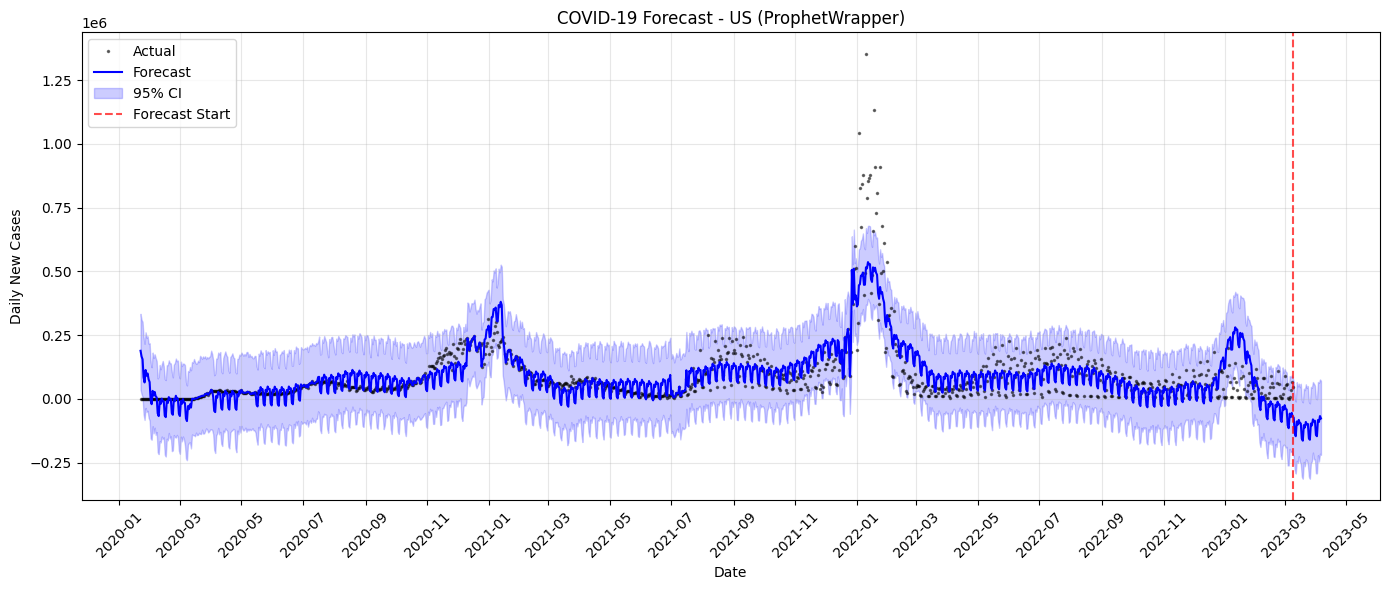

In [33]:
# Use wrapper's custom plot function
fig = plot_forecast(
    df, 
    forecast,
    title='COVID-19 Forecast - US (ProphetWrapper)',
    ylabel='Daily New Cases',
    figsize=(14, 6)
)
plt.show()

### 2.6 Cross-Validation with Wrapper

In [35]:
# Cross-validation through wrapper
wrapper_cv = ProphetWrapper().set_holidays(holidays_df).fit(df)

cv_results = wrapper_cv.cross_validate(
    initial='365 days',
    period='30 days',
    horizon='28 days'
)

# Get metrics
cv_metrics = wrapper_cv.get_performance_metrics(cv_results)
print("Cross-validation metrics:")
cv_metrics[['horizon', 'rmse', 'mae', 'smape']].head()

05:38:19 - cmdstanpy - INFO - Chain [1] start processing
05:38:19 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.


  0%|          | 0/25 [00:00<?, ?it/s]

05:38:19 - cmdstanpy - INFO - Chain [1] start processing
05:38:19 - cmdstanpy - INFO - Chain [1] done processing
05:38:19 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
05:38:19 - cmdstanpy - INFO - Chain [1] start processing
05:38:24 - cmdstanpy - INFO - Chain [1] done processing
05:38:24 - cmdstanpy - INFO - Chain [1] start processing
05:38:24 - cmdstanpy - INFO - Chain [1] done processing
05:38:24 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
05:38:24 - cmdstanpy - INFO - Chain [1] start processing
05:38:27 - cmdstanpy - INFO - Chain [1] done processing
05:38:27 - cmdstanpy - INFO - Chain [1] start processing
05:38:28 - cmdstanpy - INFO - Chain [1] done processing
05:38:28 - cmdstanpy - INFO - Chain [1] start processing
05:38:28 - cmdstanpy - INFO - Chain [1] done processing
05:38:28 - cmdstanpy - INFO - Chain [1] 

Cross-validation metrics:


,horizon,rmse,mae,smape
0,3 days,113390.042182,67882.333585,0.654562
1,4 days,124299.790317,74964.327442,0.680234
2,5 days,123749.870745,74205.040126,0.650057
3,6 days,113929.832972,72004.689257,0.646127
4,7 days,110501.983014,72363.202651,0.650795


### 2.7 Extract Components

In [36]:
# Get decomposed components
components = wrapper.get_components()

print("Available components:")
for name, comp in components.items():
    if comp is not None:
        print(f"  {name}: {comp.shape}")

Available components:
  trend: (1171, 2)
  weekly: (1171, 2)
  yearly: (1171, 2)
  holidays: (1171, 13)


### 2.8 Multi-Country Comparison

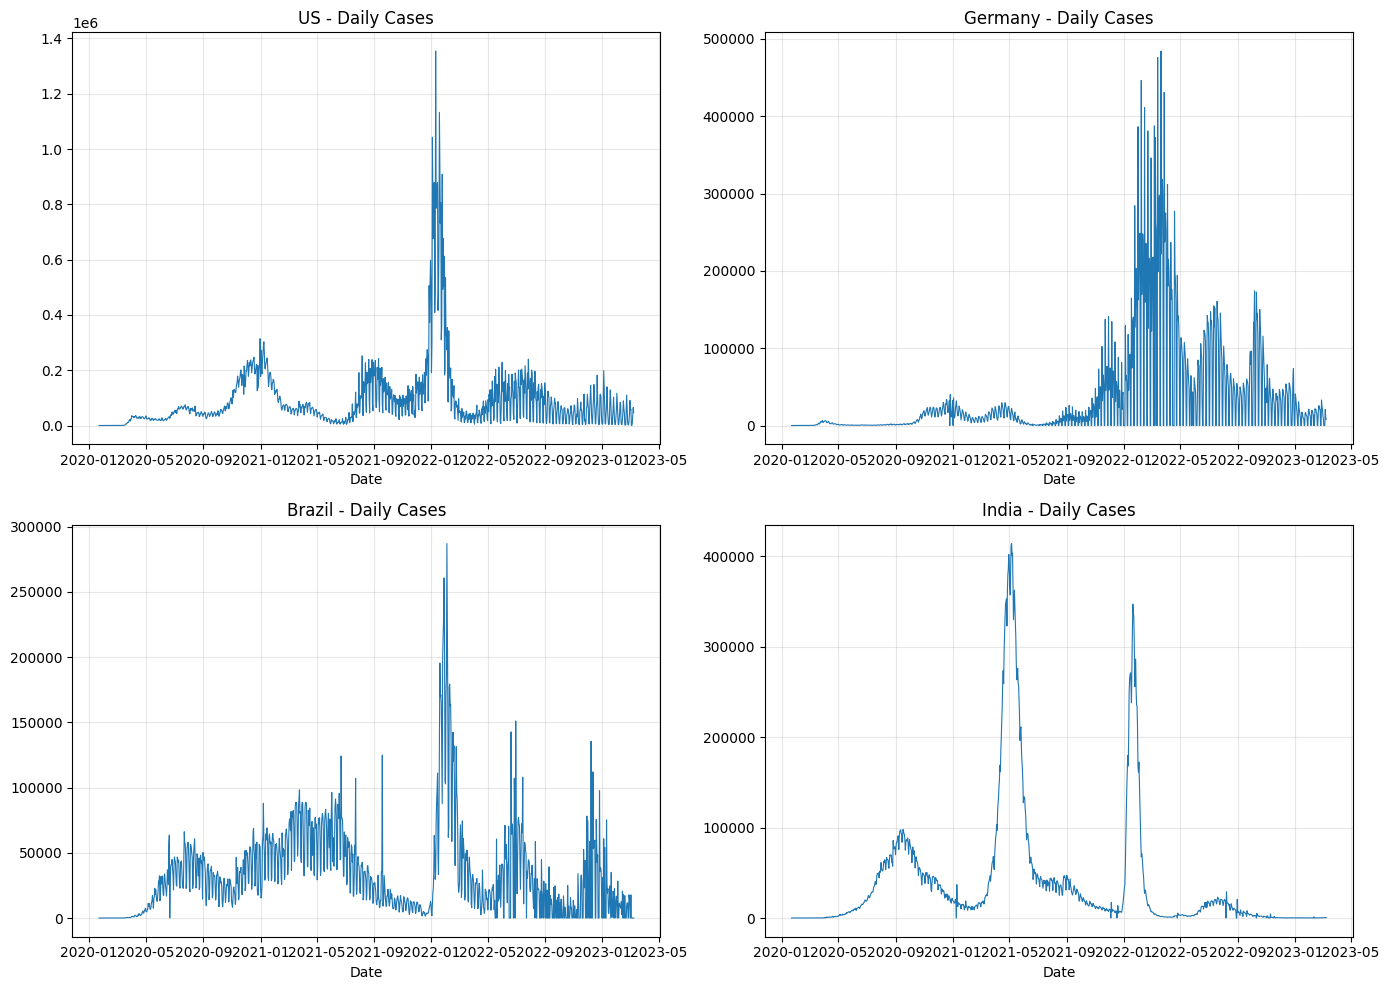

In [37]:
# Load data for multiple countries
countries = ['US', 'Germany', 'Brazil', 'India']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, country in zip(axes, countries):
    try:
        country_df = load_jhu_timeseries(DATA_PATH, country=country)
        ax.plot(country_df['ds'], country_df['y'], linewidth=0.8)
        ax.set_title(f'{country} - Daily Cases')
        ax.set_xlabel('Date')
        ax.grid(True, alpha=0.3)
    except Exception as e:
        ax.set_title(f'{country} - Error: {e}')

plt.tight_layout()
plt.show()

---

## Part 3: Native vs Wrapper Comparison

In [38]:
print("="*60)
print("COMPARISON: Native Prophet API vs Wrapper Layer")
print("="*60)

print("\n--- Native Prophet API ---")
print("""
# More verbose, more control
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    holidays=holidays_df,
    changepoint_prior_scale=0.05
)
model.add_regressor('temperature')
model.fit(df)
future = model.make_future_dataframe(periods=30)
future['temperature'] = get_future_temps()
forecast = model.predict(future)
""")

print("\n--- Wrapper Layer ---")
print("""
# Cleaner, method chaining, sensible defaults
wrapper = (ProphetWrapper()
    .set_holidays(holidays_df)
    .add_regressor('temperature')
    .fit(df)
)
forecast = wrapper.predict(periods=30)
""")

print("\n" + "="*60)
print("Key Benefits of Wrapper:")
print("  1. Method chaining for cleaner code")
print("  2. Pre-configured for COVID-19 data (weekly seasonality, etc.)")
print("  3. JHU data loader with automatic cumulative-to-daily conversion")
print("  4. Built-in evaluation metrics (RMSE, MAE, SMAPE)")
print("  5. Pre-defined intervention dates for multiple countries")
print("  6. Custom visualizations for forecasts and interventions")
print("="*60)

COMPARISON: Native Prophet API vs Wrapper Layer

--- Native Prophet API ---

# More verbose, more control
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    holidays=holidays_df,
    changepoint_prior_scale=0.05
)
model.add_regressor('temperature')
model.fit(df)
future = model.make_future_dataframe(periods=30)
future['temperature'] = get_future_temps()
forecast = model.predict(future)


--- Wrapper Layer ---

# Cleaner, method chaining, sensible defaults
wrapper = (ProphetWrapper()
    .set_holidays(holidays_df)
    .add_regressor('temperature')
    .fit(df)
)
forecast = wrapper.predict(periods=30)


Key Benefits of Wrapper:
  1. Method chaining for cleaner code
  2. Pre-configured for COVID-19 data (weekly seasonality, etc.)
  3. JHU data loader with automatic cumulative-to-daily conversion
  4. Built-in evaluation metrics (RMSE, MAE, SMAPE)
  5. Pre-defined intervention dates for multiple countries
  6. Custom visualizations for forecasts and interventions

---

## Summary

This notebook demonstrated:

### Native Prophet API
- Basic model creation and fitting
- Adding holidays and external regressors
- Cross-validation and performance metrics
- Built-in visualization

### Wrapper Layer (`prophet_utils.py`)
- `load_jhu_timeseries()` for Johns Hopkins data (1,143 days, 200+ countries)
- `ProphetWrapper` class with method chaining
- `get_us_covid_interventions()` for pre-defined intervention dates
- Custom evaluation metrics including SMAPE
- Enhanced visualizations

### Comparison Table

| Feature | Native Prophet | Wrapper Layer |
|---------|---------------|---------------|
| Data Loading | Manual | `load_jhu_timeseries()` |
| Configuration | Verbose | Method chaining |
| Interventions | Manual DataFrame | `get_us_covid_interventions()` |
| SMAPE Metric | Not included | Built-in |
| COVID Defaults | Manual setup | Pre-configured |
| Multi-country | Manual | `get_country_interventions()` |

See `Prophet.example.ipynb` for a complete COVID-19 forecasting application.